# Section B

## Part-1

### 1. Read and preprocess traffic images (grayscale conversion and noise removal)

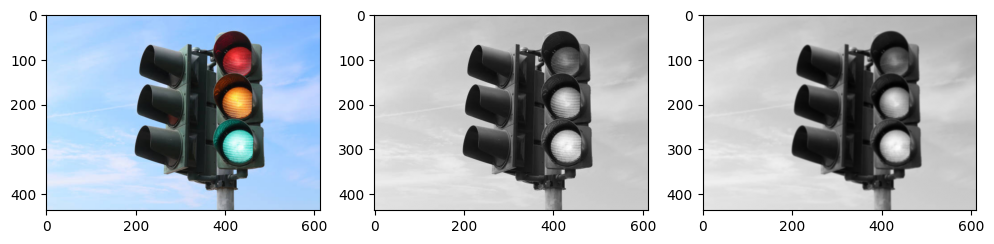

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/traffic_signal.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
# Noise Removal
noise_removed = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(12, 4))

# Plotting original image
plt.subplot(1, 3, 1)
plt.imshow(img)

# Plotting gray image
plt.subplot(1, 3, 2)
plt.imshow(gray, cmap='gray')

# Plotting noise removed image
plt.subplot(1, 3, 3)
plt.imshow(noise_removed, cmap='gray')

2. Implement HOG feature extraction
, Sliding window technique for vehicle detection. Display detection results.

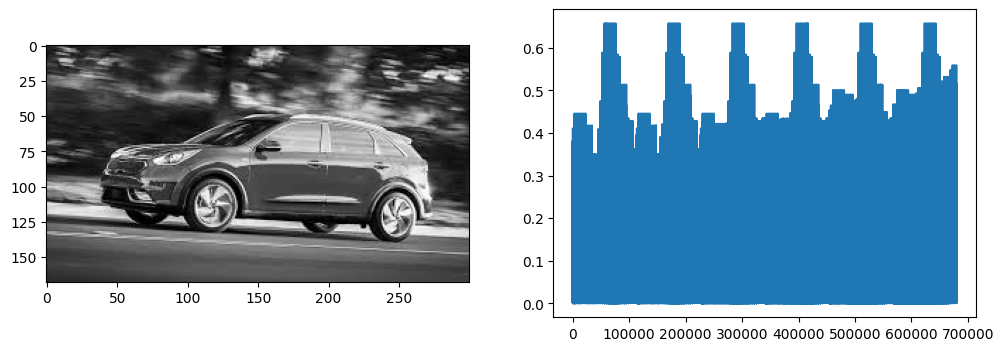

In [ ]:
img = cv2.imread('/content/car.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hog = cv2.HOGDescriptor()
hog_features = hog.compute(img)

# hog_image = hog.computeGradient(img)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.plot(hog_features)
plt.show()

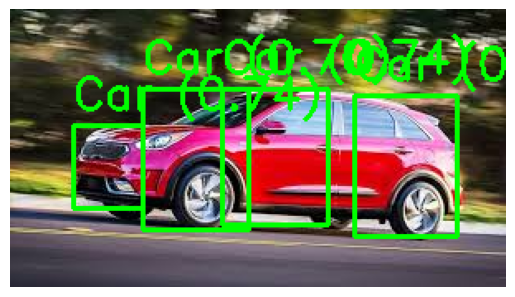

In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt

# Sliding window function
def sliding_window(image, window_size, step_size):
    for y in range(0, image.shape[0] - window_size[1] + 1, step_size[1]):
        for x in range(0, image.shape[1] - window_size[0] + 1, step_size[0]):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

# Non-Maximum Suppression to remove redundant boxes
def non_max_suppression(boxes, scores, threshold=0.5):
    # Convert to appropriate format for OpenCV NMS
    indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold=threshold, nms_threshold=0.4)
    return indices

def main():
    # Load the pre-trained model from TensorFlow Hub
    model_url = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"  # Example model for object detection
    model = hub.load(model_url)

    # Read the image and convert it to RGB (OpenCV loads images in BGR format)
    image = cv2.imread('/content/car.jpg')
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Define sliding window parameters
    window_size = (64, 128)  # Typical size for vehicle detection
    step_size = (16, 16)     # Slide by 16 pixels in both directions

    # Preprocess image for the model
    image_resized = cv2.resize(image_rgb, (300, 300))  # Resize to a standard input size for the model
    input_tensor = tf.convert_to_tensor(image_resized)
    input_tensor = input_tensor[tf.newaxis,...]

    # Get the image dimensions
    h, w = image.shape[:2]

    # Initialize lists to store boxes and scores for NMS
    boxes_list = []
    scores_list = []

    for (x, y, window) in sliding_window(image_rgb, window_size, step_size):
        # Resize the window for model input
        window_resized = cv2.resize(window, (300, 300))
        window_tensor = tf.convert_to_tensor(window_resized)
        window_tensor = window_tensor[tf.newaxis,...]

        # Run inference on the current window
        detections = model(window_tensor)

        # Extract the detection results
        boxes = detections['detection_boxes'][0].numpy()
        classes = detections['detection_classes'][0].numpy()
        scores = detections['detection_scores'][0].numpy()

        # Check if detection is strong enough (thresholding)
        threshold = 0.5
        for i in range(boxes.shape[0]):
            if scores[i] > threshold and int(classes[i]) == 3:  # Class 3 is for cars in COCO dataset
                # Get box coordinates and scale them back to the original image dimensions
                y_min, x_min, y_max, x_max = boxes[i]
                start_point = (int((x + x_min * window_size[0])), int((y + y_min * window_size[1])))
                end_point = (int((x + x_max * window_size[0])), int((y + y_max * window_size[1])))

                # Append box and score to the lists
                boxes_list.append([start_point[0], start_point[1], end_point[0], end_point[1]])
                scores_list.append(scores[i])

    # Apply Non-Maximum Suppression (NMS) to remove overlapping boxes
    indices = non_max_suppression(boxes_list, scores_list, threshold=0.5)

    # Ensure indices is not empty and handle it correctly
    if len(indices) > 0:
        # Indices returned by cv2.dnn.NMSBoxes is a 2D array of indices
        # Access the indices of the boxes to keep
        indices = indices.flatten()  # Flatten the array to get a 1D array of indices
        # Draw remaining bounding boxes after NMS
        for i in indices:  # Loop over the indices
            box = boxes_list[i]
            score = scores_list[i]
            start_point = (box[0], box[1])
            end_point = (box[2], box[3])

            # Draw bounding box and label on the image
            cv2.rectangle(image, start_point, end_point, (0, 255, 0), 2)
            cv2.putText(image, f'Car ({score:.2f})', (start_point[0], start_point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    else:
        print("No valid detections after NMS.")

    # Convert the image back to BGR for OpenCV to display
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # Show the resulting image
    plt.imshow(image_bgr)
    plt.axis('off')  # Hide axes for better visualization
    plt.show()

main()

### 3. Apply Selective Search and visualize region proposals using bounding boxes.

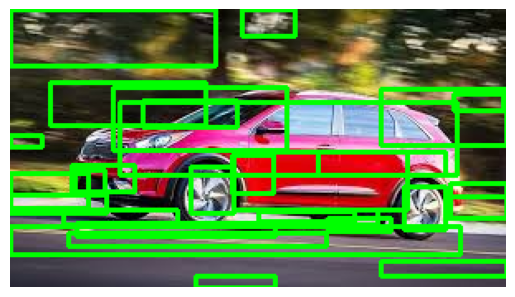

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread('/content/car.jpg')

# Initialize selective search
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()

# Set the input image
ss.setBaseImage(image)

# Select the strategy for selective search (we can choose different types of strategies)
# Here, we use 'fast' mode which is faster and less accurate. You can use 'quality' for higher accuracy.
ss.switchToSelectiveSearchFast()

# Get the candidate regions (bounding boxes)
rects = ss.process()

# Draw the bounding boxes on the image
for rect in rects[:30]:
    x, y, w, h = rect
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw a green box

# Convert the image from BGR (OpenCV default) to RGB (for display in Matplotlib)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the output
plt.imshow(image_rgb)
plt.axis('off')  # Hide the axes for a clean display
plt.show()

## Part 2

### 1. Implement object detection using YOLO for vehicle detection.

In [ ]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.4 MB/s eta 0:00:00



0: 384x640 1 car, 7.0ms
Speed: 1.5ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


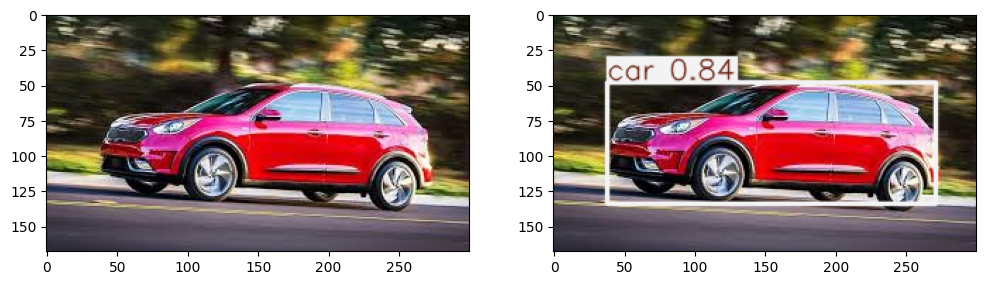

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("yolov8n.pt")
img = cv2.imread("/content/car.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result = model(img)

# Plotting the result
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(result[0].plot())

### 2. Evaluate detection performance using precision, recall, and IoU.

In [ ]:
def compute_iou(box1, box2):
    # Coordinates of the first box
    x1, y1, w1, h1 = box1
    # Coordinates of the second box
    x2, y2, w2, h2 = box2

    # Calculate the coordinates of the intersection box
    x_left = max(x1, x2)
    y_top = max(y1, y2)
    x_right = min(x1 + w1, x2 + w2)
    y_bottom = min(y1 + h1, y2 + h2)

    # Check if there is an intersection
    if x_right < x_left or y_bottom < y_top:
        return 0.0  # No intersection

    # Calculate the area of the intersection
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # Calculate the area of both bounding boxes
    box1_area = w1 * h1
    box2_area = w2 * h2

    # Calculate the area of the union
    union_area = box1_area + box2_area - intersection_area

    # Calculate IoU
    iou = intersection_area / union_area
    return iou

# Define two dummy bounding boxes (x, y, width, height)
box1 = [50, 50, 100, 100]  # Box 1: top-left (50, 50), width 100, height 100
box2 = [75, 75, 100, 100]  # Box 2: top-left (75, 75), width 100, height 100

# Compute IoU
iou = compute_iou(box1, box2)

print(f"IoU between the two boxes: {iou:.2f}")

# Define the values for TP, FP, FN (using arbitrary values for illustration)
TP = 50  # True Positives
FP = 10  # False Positives
FN = 5   # False Negatives

# Compute Precision
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

# Compute Recall
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

# IoU is usually computed for each pair of predicted and ground truth boxes
# Assuming an IoU of 0.75 for illustration purposes (can vary per box)
iou = iou  # Given as a constant in this example, but in practice, it's calculated per bounding box.

# Display the results
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

IoU between the two boxes: 0.39
Precision: 0.83
Recall: 0.91
